# Wing detection image preprocess for model training

In [275]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from wings.config import PROCESSED_DATA_DIR, PROJ_ROOT

dataset_path = PROCESSED_DATA_DIR / "detection" / "dataset.ndjson"

image_records = []
with dataset_path.open("r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if rec.get("type") == "image" and rec.get("annotations", {}).get("boxes"):
            image_records.append(rec)


len(image_records)

21722

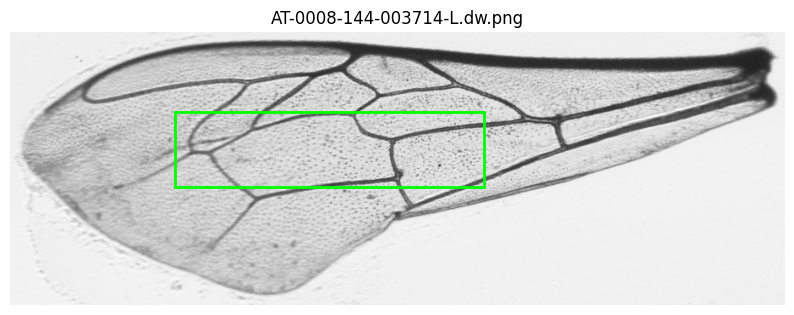

In [276]:
sample = random.choice(image_records)

img_path = PROJ_ROOT / Path(sample["file"])
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# YOLO box format: [class_id, cx, cy, bw, bh] (normalized)
class_id, cx, cy, bw, bh = sample["annotations"]["boxes"][0]
x1 = int((cx - bw / 2) * w)
y1 = int((cy - bh / 2) * h)
box_w = int(bw * w)
box_h = int(bh * h)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
)
ax.set_title(f"{img_path.name}")
ax.axis("off")
plt.show()

# Enlarge image

In [277]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES

image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)
import random

sample_path = random.choice(image_paths)
sample_path

2026-04-23 11:01:26.473 | INFO     | wings.detection.dataset:collect_image_paths:23 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


WindowsPath('C:/Users/X/projects/bees/data/raw/RO-wing-images/RO-0143-MH-41-2016-001739.dw.png')

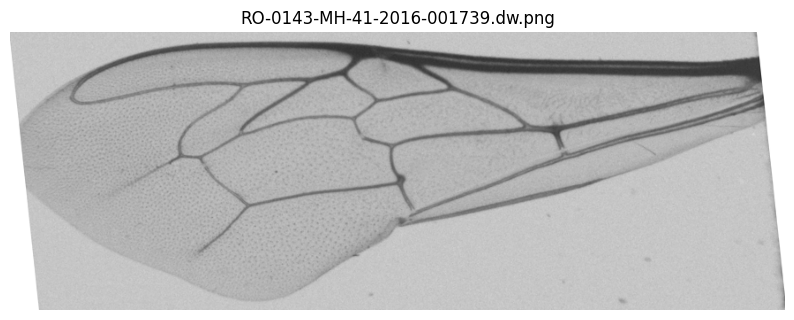

In [278]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {sample_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()

In [279]:
def stretch_edges_outward(image_path: str, pad: int):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Nie udało się wczytać obrazu: {image_path}")

    padded = cv2.copyMakeBorder(
        img,
        top=pad,
        bottom=pad,
        left=pad,
        right=pad,
        borderType=cv2.BORDER_REPLICATE
    )

    return padded


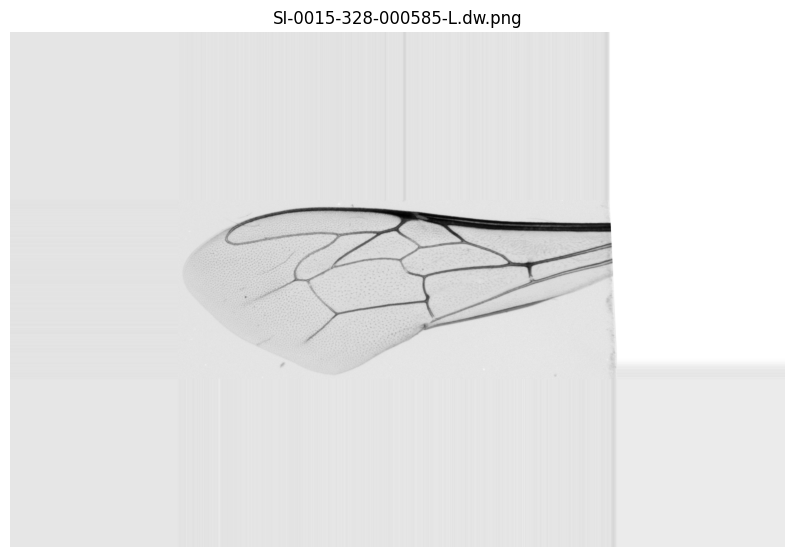

In [280]:
sample_path = random.choice(image_paths)
result = stretch_edges_outward(sample_path, 300)
img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np

def pad_with_most_common_edge_colors(image_path: str, pad: int):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(image_path)

    def most_common(arr):
        colors, counts = np.unique(arr.reshape(-1, arr.shape[-1]) if arr.ndim == 2 else arr.reshape(-1, 1), axis=0, return_counts=True)
        return colors[counts.argmax()]

    top = most_common(img[0])
    bottom = most_common(img[-1])
    left = most_common(img[:, 0])
    right = most_common(img[:, -1])

    h, w = img.shape[:2]
    out = np.zeros((h + 2 * pad, w + 2 * pad, *img.shape[2:]), dtype=img.dtype)

    out[pad:pad+h, pad:pad+w] = img
    out[:pad, pad:pad+w] = top
    out[pad+h:, pad:pad+w] = bottom
    out[pad:pad+h, :pad] = left
    out[pad:pad+h, pad+w:] = right

    out[:pad, :pad] = top
    out[:pad, pad+w:] = top
    out[pad+h:, :pad] = bottom
    out[pad+h:, pad+w:] = bottom

    return out

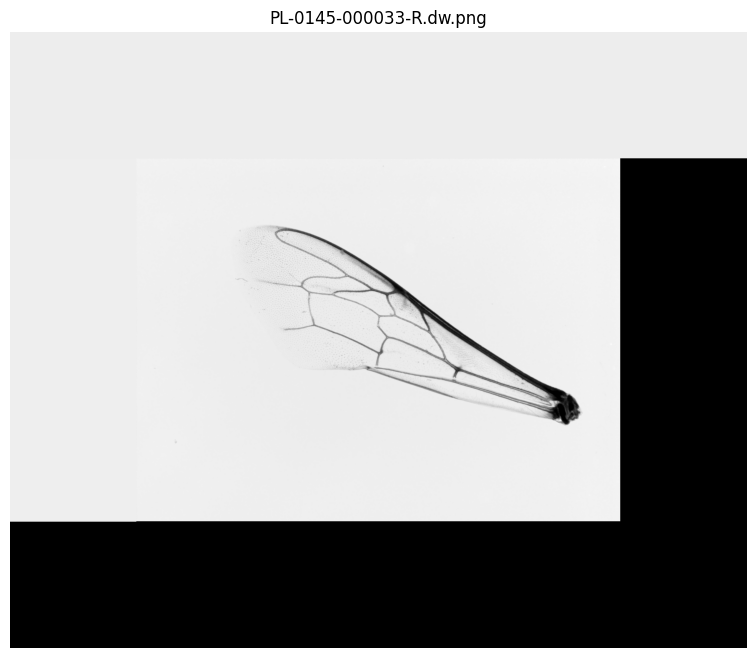

In [282]:
sample_path = random.choice(image_paths)
result = pad_with_most_common_edge_colors(sample_path, 300)
img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()

C:\Users\X\projects\bees\data\raw\RO-wing-images\RO-0184-SV-23-2019-000471-R.dw.png
(227, 227, 227)


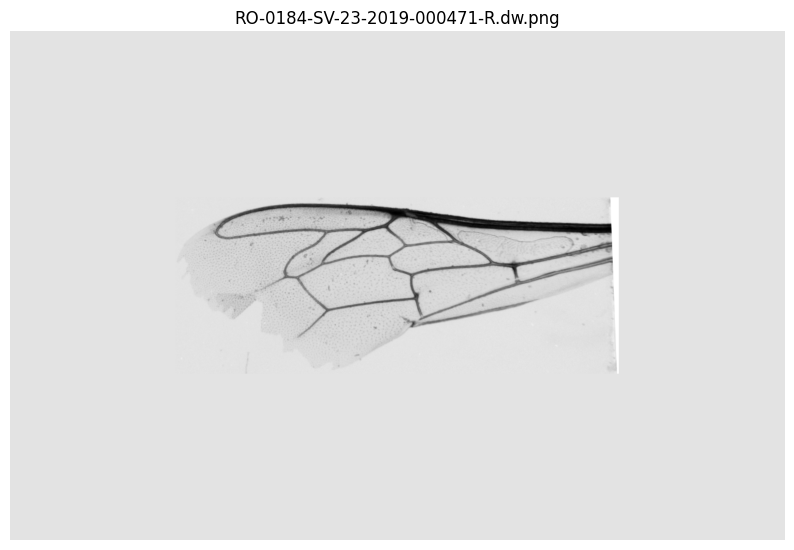

In [283]:
import cv2
import numpy as np

sample_path = random.choice(image_paths)
print(sample_path)
img = cv2.imread(sample_path)
d=5
frame = np.concatenate([img[d], img[-d-1], img[:, d], img[:, -d-1]])
colors, counts = np.unique(frame, axis=0, return_counts=True)
color = tuple(map(int, colors[counts.argmax()]))
print(color)

out = cv2.copyMakeBorder(img, 300, 300, 300, 300, cv2.BORDER_CONSTANT, value=color)
img_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()

In [284]:
def dominant_inner_border_color(img, offset=2, width=5, q=8):
    frame = np.concatenate([
        img[offset:offset+width].reshape(-1, 3),
        img[-offset-width:-offset].reshape(-1, 3),
        img[:, offset:offset+width].reshape(-1, 3),
        img[:, -offset-width:-offset].reshape(-1, 3),
    ])

    frame_q = (frame // q) * q
    colors, counts = np.unique(frame_q, axis=0, return_counts=True)
    return tuple(map(int, colors[counts.argmax()]))



def pad_with_dominant_border_color(image_path, pad, offset=2, width=5, q=8):
    img = cv2.imread(image_path)
    color = dominant_inner_border_color(img, offset=offset, width=width, q=q)
    out = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=color)
    return out

C:\Users\X\projects\bees\data\raw\HR-wing-images\HR-0023-038-101051-L.dw.png


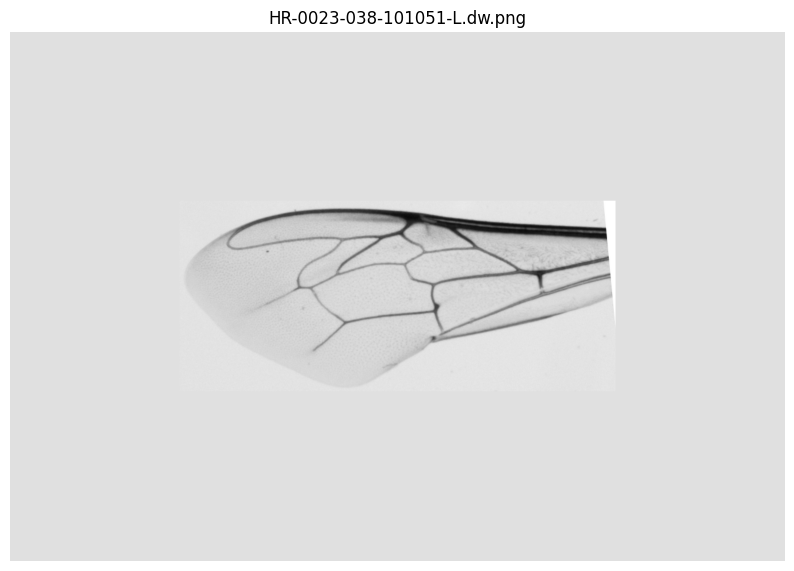

In [285]:
sample_path = random.choice(image_paths)
print(sample_path)

out = pad_with_dominant_border_color(sample_path, 300)
img_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()

# Final function

In [286]:
from numpy.typing import NDArray

def is_near_white(color: tuple[int, int, int], threshold: int = 240) -> bool:
    return all(c >= threshold for c in color)


def fill_white_spots(
    img: NDArray[np.uint8],
    fill_color: tuple[int, int, int],
    white_threshold: int = 245,
) -> NDArray[np.uint8]:
    out = img.copy()
    mask = np.all(out >= white_threshold, axis=2)
    out[mask] = fill_color
    return out



def pad_image(img: NDArray[np.uint8], pad: tuple[int, int, int, int], *, d = 5, offset=2, width=5, q=8,white_threshold: int = 245, near_white_threshold: int = 240):
    frame = np.concatenate([img[d], img[-d-1], img[:, d], img[:, -d-1]])
    colors, counts = np.unique(frame, axis=0, return_counts=True)
    color = tuple(map(int, colors[counts.argmax()]))
    if color in [(255, 255, 255), (0, 0, 0)]:
        color = dominant_inner_border_color(img, offset=offset, width=width, q=q)

    if not is_near_white(color, threshold=near_white_threshold):
        img = fill_white_spots(img, color, white_threshold=white_threshold)


    out = cv2.copyMakeBorder(img, *pad, cv2.BORDER_CONSTANT, value=color)
    return out

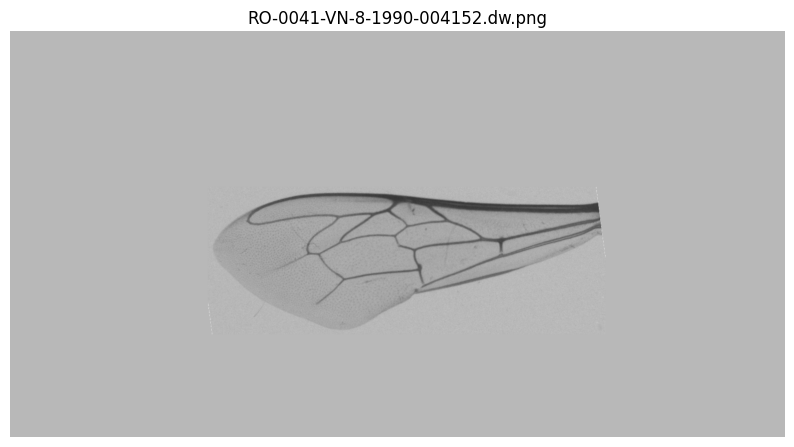

In [436]:
sample_path = random.choice(image_paths)
img = cv2.imread(sample_path)
pad_values = tuple(np.random.randint(100, 500) for _ in range(4))
padded = pad_image(img, pad_values)

img_rgb = cv2.cvtColor(padded, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()